# Purpose:
- Analyzing OMC results (after dev)
- Focusing on z-drift only for now.
    - Consider fluorescence signal later

In [57]:
from split_reg_emf import _extract_dict_from_si_string, create_plane_h5_from_tiff, register_plane_and_save_emf
from pathlib import Path
from ScanImageTiffReader import ScanImageTiffReader
import tifffile
from dask import delayed, compute
from dask.distributed import Client
from time import time
import numpy as np
import pandas as pd
import h5py
from matplotlib import pyplot as plt

from lamf_analysis.ophys import zdrift

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Split, register, segment, and save them all

In [3]:
def split_reg_emf(
    data_fn: str,
    num_planes: int = 8,
    num_threads: int = 10,
    epoch_minutes: int = 1,
):
    """
    Splits a ScanImageTiffReader file into multiple h5 files and registers them to create an EMF.

    Parameters
    ----------
    data_fn : str
        Path to the input TIFF file.
    num_planes : int
        Number of planes to split the TIFF file into.
    num_threads : int
        Number of threads to use for processing.
    epoch_minutes : int
        Time in minutes for each epoch.

    Returns
    -------
    None
    """

    # get metadata from tiff file
    with ScanImageTiffReader(str(data_fn)) as reader:
        md_string = reader.metadata()

    with tifffile.TiffFile(data_fn) as tif:
        num_pages = (len(tif.pages))

    # split si & roi groups, prep for seprate parse
    s = md_string.split("\n{")
    rg_str = "{" + s[1]
    si_str = s[0]

    # parse 1: extract keys and values, dump, then load again
    si_metadata = _extract_dict_from_si_string(si_str)
    frame_rate = float(si_metadata['SI.hRoiManager.scanVolumeRate'])

    with Client() as client:
        tasks = [delayed(create_plane_h5_from_tiff)(data_fn, pi, num_pages, num_planes) for pi in range(num_planes)]
        results = compute(*tasks, num_workers=num_threads)

        tasks = [delayed(register_plane_and_save_emf)(h5_fn, frame_rate, epoch_minutes) for h5_fn in results]
        compute(*tasks, num_workers=num_threads)


In [5]:
# this takes too long.
# use HPC (15 min session takes about 6 minutes)
data_dir = Path(r'\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250423_783551')
filenames = ['1433053813_timeseries_00013.tif',
            '1433053813_timeseries_00014.tif',
]

for fn in filenames:
    t0 = time()
    data_fn = data_dir / fn
    print(f'Processing {data_fn}')
    split_reg_emf(
        data_fn,
        num_planes=8,
        num_threads=8,
        epoch_minutes=1,
    )
    t1 = time()
    print(f'Finished {data_fn} in {t1-t0:.2f} seconds')

Processing \\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250423_783551\1433053813_timeseries_00013.tif
Finished \\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250423_783551\1433053813_timeseries_00013.tif in 2952.71 seconds
Processing \\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250423_783551\1433053813_timeseries_00014.tif
Finished \\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250423_783551\1433053813_timeseries_00014.tif in 1584.89 seconds


## how to use HPC
- sbatch_split_reg_emf_slurm.py
- change parameters (directory, num_planes, epoch duration)

# z-drift calculation
- There is HPC code, but it needs modification
    - File formats changed. Also we can depend on the file naming convention.
        - It will be faster and more reliable.
    - Try this for 2 calculations
        1. Z-drift and correlation calculation during OMC (from single frames, using the information in the csv file)
            - To test if we can improve estimation algorithm, especially for low SNR images (deepest plane)
        2. Z-drift calculation using EMF.
    - Compare this with the estimation and correction log.
        - We don't have the correction log yet (04/25/2025)
    


In [5]:
data_dir = Path(r'\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\250423_783551')
zstack_dir = data_dir / 'sorted_local_z_stacks'
file_inds = [13, 14] # index of files to process
filenames_all = data_dir.glob('*.tif*')
session_names = np.unique([f.stem.split('_')[0] for f in filenames_all])
assert len(session_names) == 1
session_name = int(session_names[0])

## 1. z-drift (both OMC and post-hoc)

In [159]:
fn.stem

'1433053813_timeseries_00013_07_emf'

In [6]:
file_ind = file_inds[0]
reg_filenames = list(data_dir.glob(f'{session_name}_timeseries_{file_ind:05}_*_reg.h5'))
num_planes = len(reg_filenames)
# check filename format
reg_filenames_confirm = [data_dir / f'{session_name}_timeseries_{file_ind:05}_{pi:02}_reg.h5' for pi in range(num_planes)]
assert reg_filenames == reg_filenames_confirm, f'Filename format mismatch: {reg_filenames} != {reg_filenames_confirm}'

emf_filenames = [fn.parent / f'{fn.name.split("_reg")[0]}_emf.h5' for fn in reg_filenames]
for fn in emf_filenames:
    assert fn.exists()

In [161]:
FOV_ORDER_DICT = {
    0: '0_reg_ch_1',
    1: '0_reg_ch_2',
    2: '1_reg_ch_1',
    3: '1_reg_ch_2',
    4: '2_reg_ch_1',
    5: '2_reg_ch_2',
    6: '3_reg_ch_1',
    7: '3_reg_ch_2',
}

def get_zstack(zstack_dir, plane_ind):
    matched_zstack_key = FOV_ORDER_DICT[plane_ind]
    matched_zstack_fn = list(zstack_dir.glob(f'*_local_z_stack{matched_zstack_key}.tif'))
    assert len(matched_zstack_fn) == 1
    matched_zstack_fn = matched_zstack_fn[0]
    zstack = tifffile.imread(matched_zstack_fn)
    return zstack, matched_zstack_fn


def get_motion_range(ops_fn):
    ops = np.load(ops_fn, allow_pickle=True).item()
    y_offs = ops['reg_result'][4][0]
    x_offs = ops['reg_result'][4][1]
    assert max(y_offs) > 0
    assert min(y_offs) < 0
    assert max(x_offs) > 0
    assert min(x_offs) < 0
    range_y = [max(y_offs), min(y_offs)]
    range_x = [max(x_offs), min(x_offs)]
    return range_y, range_x


def calculate_zdrift(zstack, emf, range_y, range_x,
                     use_clahe=True, use_valid_pix=True):
    # prepare zstack and crop emf
    zstack_crop = zstack[:, range_y[0]:range_y[1], range_x[0]:range_x[1]]
    stack_pre = zdrift.med_filt_z_stack(zstack_crop)
    stack_pre = zdrift.rolling_average_stack(stack_pre)    
    episodic_mean_fovs_crop = emf[:, range_y[0]:range_y[1], range_x[0]:range_x[1]]

    # calculate
    matched_plane_indices = np.zeros(episodic_mean_fovs_crop.shape[0], dtype=int)
    corrcoef = []
    segment_reg_imgs = []
    shift_list = []
    for i in range(episodic_mean_fovs_crop.shape[0]):
        fov_reg_stack, cc, shift = zdrift.fov_stack_register_phase_correlation(
            episodic_mean_fovs_crop[i], stack_pre, use_clahe=use_clahe,
            use_valid_pix=use_valid_pix)
        matched_plane_indices[i] = np.argmax(cc)
        corrcoef.append(cc)
        segment_reg_imgs.append(fov_reg_stack[np.argmax(cc)])
        shift_list.append(shift)
    corrcoef = np.asarray(corrcoef)

    results = {'matched_plane_indices': matched_plane_indices,
                'corrcoef': corrcoef,
                'segment_fov_registered': segment_reg_imgs,
                'ref_zstack_crop': zstack_crop,                   
                'shift': shift_list,
                'use_clahe': use_clahe,
                'use_valid_pix': use_valid_pix}
    return results

In [23]:
# takes about 3 minutes per plane (of 15 minutes session)
num_planes = 8
reg_filenames = list(data_dir.glob(f'{session_name}_timeseries_{file_ind:05}_*_reg.h5'))
assert num_planes == len(reg_filenames)
# check filename format
reg_filenames_confirm = [data_dir / f'{session_name}_timeseries_{file_ind:05}_{pi:02}_reg.h5' for pi in range(num_planes)]
assert reg_filenames == reg_filenames_confirm, f'Filename format mismatch: {reg_filenames} != {reg_filenames_confirm}'

emf_filenames = [fn.parent / f'{fn.name.split("_reg")[0]}_emf.h5' for fn in reg_filenames]
ops_filenames = [fn.parent / f'{fn.name.split("_reg")[0]}_ops.npy' for fn in reg_filenames]
assert np.all([fn.exists() for fn in emf_filenames]), f'Not all emf files exist: {emf_filenames}'
assert np.all([fn.exists() for fn in ops_filenames]), f'Not all ops files exist: {ops_filenames}'

results_session = []
for plane_ind in range(num_planes):
    emf_fn = emf_filenames[plane_ind]
    ops_fn = ops_filenames[plane_ind]
    with h5py.File(emf_fn, 'r') as f:
        emf = f['data'][:]
    y_range, x_range = get_motion_range(ops_fn)
    zstack, matched_zstack_fn  = get_zstack(zstack_dir, plane_ind)
    
    results = calculate_zdrift(zstack, emf, y_range, x_range)
    results['plane_ind'] = plane_ind
    results['emf_fn'] = emf_fn
    results['ops_fn'] = ops_fn
    results['zstack_fn'] = matched_zstack_fn
    results_session.append(results)
        

In [35]:
def wrapper_calcualte_zdrift(plane_ind, emf_fn, ops_fn, zstack_dir):
    with h5py.File(emf_fn, 'r') as f:
        emf = f['data'][:]
    y_range, x_range = get_motion_range(ops_fn)
    zstack, matched_zstack_fn  = get_zstack(zstack_dir, plane_ind)
    
    results = calculate_zdrift(zstack, emf, y_range, x_range)
    results['plane_ind'] = plane_ind
    results['emf_fn'] = emf_fn
    results['ops_fn'] = ops_fn
    results['zstack_fn'] = matched_zstack_fn
    return results

In [37]:
# takes 5 minutes for 15 minutes session (using dask)

num_planes = 8
reg_filenames = list(data_dir.glob(f'{session_name}_timeseries_{file_ind:05}_*_reg.h5'))
assert num_planes == len(reg_filenames)
# check filename format
reg_filenames_confirm = [data_dir / f'{session_name}_timeseries_{file_ind:05}_{pi:02}_reg.h5' for pi in range(num_planes)]
assert reg_filenames == reg_filenames_confirm, f'Filename format mismatch: {reg_filenames} != {reg_filenames_confirm}'

emf_filenames = [fn.parent / f'{fn.name.split("_reg")[0]}_emf.h5' for fn in reg_filenames]
ops_filenames = [fn.parent / f'{fn.name.split("_reg")[0]}_ops.npy' for fn in reg_filenames]
assert np.all([fn.exists() for fn in emf_filenames]), f'Not all emf files exist: {emf_filenames}'
assert np.all([fn.exists() for fn in ops_filenames]), f'Not all ops files exist: {ops_filenames}'

with Client() as client:
    tasks = [delayed(wrapper_calcualte_zdrift)(plane_ind, emf_fn, ops_fn, zstack_dir) 
             for plane_ind, emf_fn, ops_fn in zip(range(num_planes), emf_filenames, ops_filenames)]
    results_session = compute(*tasks)

c:\Users\jinho.kim\Anaconda3\envs\omc_local\lib\site-packages\distributed\client.py:3357: UserWarning: Sending large graph of size 152.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [157]:
# save results
save_fn = data_dir / f'{session_name}_timeseries_{file_ind:05}_zdrift_results.npz'
np.savez(save_fn, data=results_session)

In [153]:
# load the results
results_npz = np.load(save_fn, allow_pickle=True)
loaded_results = results_npz['data']

C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22144\122128960.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.95, 1])  # Adjust layout to make space for the colorbar


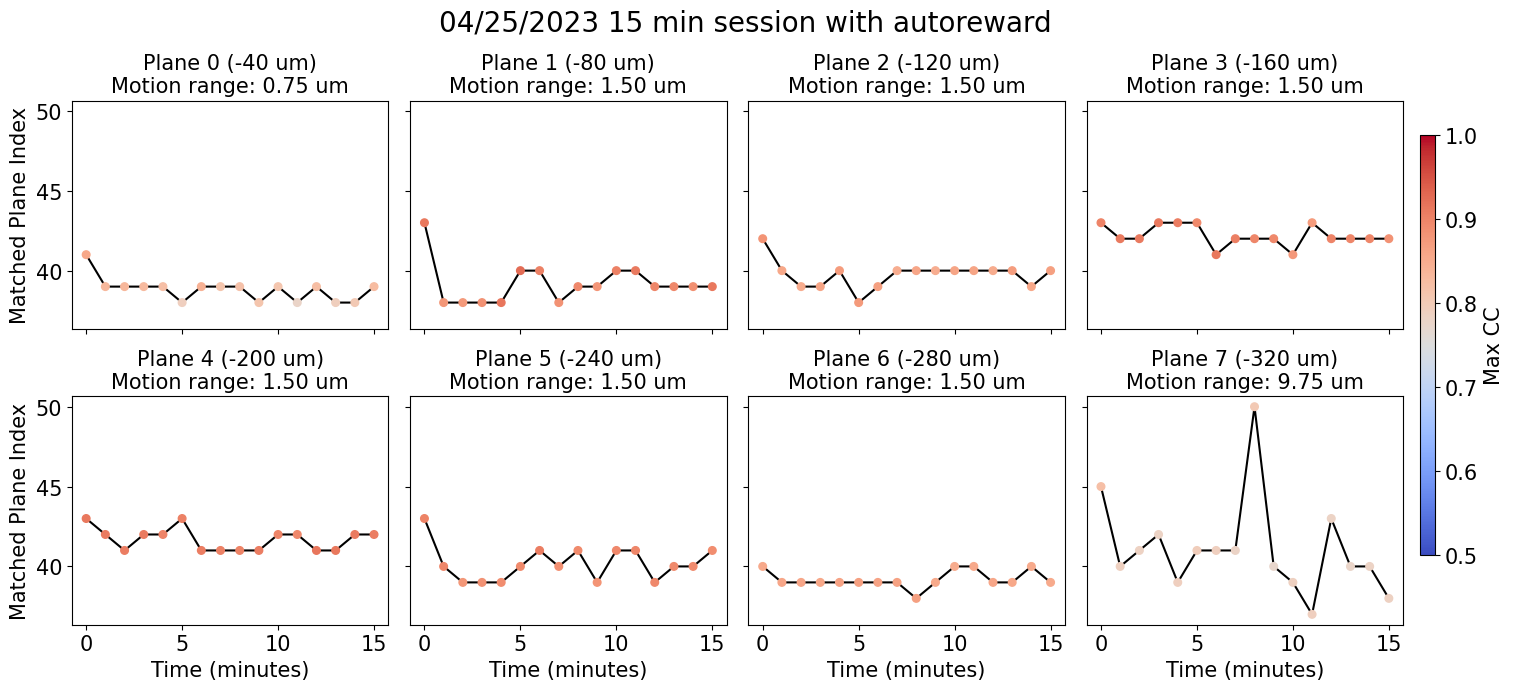

In [140]:
plane_order = [7, 5, 3, 1, 0, 2, 4, 6]
plane_depths = range(40, 330, 40)
num_planes = len(plane_order)
assert len(results_session) == num_planes
results_plane_inds = [r['plane_ind'] for r in results_session]
results_ordered = []
for plane_ind in plane_order:
    matched_ind = results_plane_inds.index(plane_ind)
    results_ordered.append(results_session[matched_ind])

fig, axes = plt.subplots(2,4, figsize=(15, 7), sharex=True, sharey=True)
for i, r in enumerate(results_ordered):
    ax = axes.flatten()[i]
    mpi = r['matched_plane_indices']
    max_range = (np.max(r['matched_plane_indices'][1:]) - np.min(r['matched_plane_indices'][1:])) * 0.75
    max_cc = [max(cc) for cc in r['corrcoef']]
    ax.plot(mpi, 'k-', label=f'Plane {i}')
    im = ax.scatter(range(len(mpi)), mpi, c=max_cc, s=30, cmap='coolwarm', vmin=0.5, vmax=1, zorder=2)
    fov_depth = plane_depths[i]
    ax.set_title(f'Plane {i} ({-fov_depth} um)\nMotion range: {max_range:.2f} um', fontsize=15)
    if i %4 == 0:
        ax.set_ylabel('Matched Plane Index', fontsize=15)
    if i >= 4:
        ax.set_xlabel('Time (minutes)', fontsize=15)        
    # if i % 4 == 3:
    #     cbar = fig.colorbar(im, ax=ax, location='right', shrink=0.8, pad=0.1)
    #     cbar.set_label('Max CC')
    ax.tick_params(axis='both', labelsize=15)
# Add a single colorbar for all subplots
cbar_ax = fig.add_axes([0.95, 0.2, 0.01, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Max CC', fontsize=15)
cbar.ax.tick_params(labelsize=15)

fig.suptitle('04/25/2023 15 min session with autoreward', fontsize=20)
fig.tight_layout(rect=[0, 0, 0.95, 1])  # Adjust layout to make space for the colorbar



In [8]:
def reformat_df(df):
    # strip blank spaces from column names
    df.columns = df.columns.str.strip()
    for col in df.columns:
        if isinstance(df[col].values[0], str):
            df[col] = df[col].str.strip()
    df['roiName'] = df['roiName'].str.strip()
    # convert str of list to a list
    def _str_to_float_list(x):
        """
        Convert a string representation of a list to a list of floats.
        """
        return [float(np.round(float(s), 4)) for s in x.split('[')[1].split(']')[0].split(' ')]
    list_columns = ['drPixel', 'drRef', 'confidence']
    for col in list_columns:
        df[col] = df[col].apply(lambda x: _str_to_float_list(x))
    return df

motion_est_fn = data_dir / f'{session_name}_timeseries_Motion_{file_ind:05}.csv'
motion_est = pd.read_csv(motion_est_fn)
motion_est = reformat_df(motion_est)


In [134]:
assert len(motion_est) % 2 == 0, f'Number of motion estimates ({len(motion_est)}) is not even'
channels = ((motion_est.index.values % 2) + 1).astype(int)
motion_est['channel'] = channels
zs = np.sort(motion_est.z.unique())
motion_est['pair_ind'] = motion_est['z'].apply(lambda x: np.where(zs == x)[0][0])

Text(0.5, 0.98, '04/25/2023 15 min session with autoreward')

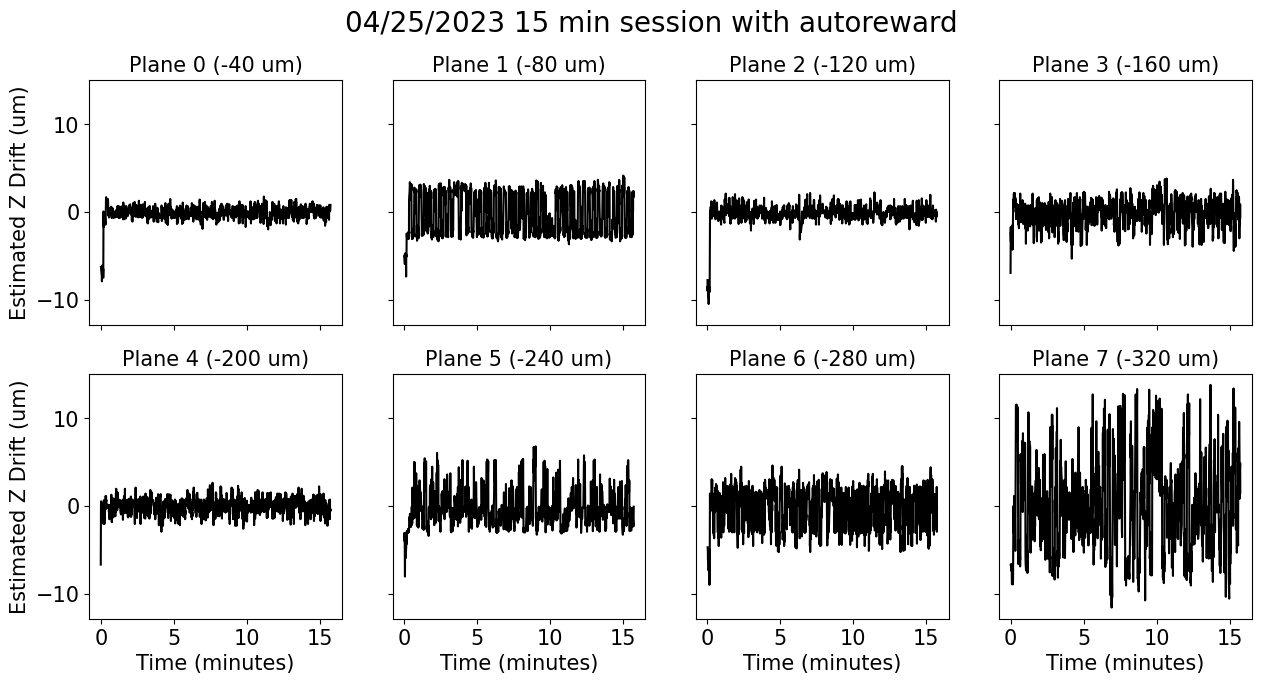

In [142]:
plane_ind_dict = {0: (3, 2),
                  1: (2, 2),
                  2: (1, 2),
                  3: (0, 2),
                  4: (0, 1),
                  5: (1, 1),
                  6: (2, 1),
                  7: (3, 1)}
plane_depths = range(40, 330, 40)

fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
for pi in range(8):
    ax = axes.flatten()[pi]
    (pair_ind, channel) = plane_ind_dict[pi]
    fov_motion_est = motion_est.query('channel == @channel and pair_ind == @pair_ind')
    fov_timestamps = fov_motion_est.timestamp.values / 60 # in minutes
    fov_zdrift = [p[2] for p in fov_motion_est.drPixel.values]

    ax.plot(fov_timestamps, fov_zdrift, 'k-')
    fov_depth = plane_depths[pi]
    ax.set_title(f'Plane {pi} ({-fov_depth} um)', fontsize=15)
    if pi % 4 == 0:
        ax.set_ylabel('Estimated Z Drift (um)', fontsize=15)
    if pi >= 4:
        ax.set_xlabel('Time (minutes)', fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
fig.suptitle('04/25/2023 15 min session with autoreward', fontsize=20)


## 2. Images

In [ ]:
reg_filenames = list(data_dir.glob(f'{session_name}_timeseries_{file_ind:05}_*_reg.h5'))
assert num_planes == len(reg_filenames)
# check filename format
reg_filenames_confirm = [data_dir / f'{session_name}_timeseries_{file_ind:05}_{pi:02}_reg.h5' for pi in range(num_planes)]
assert reg_filenames == reg_filenames_confirm, f'Filename format mismatch: {reg_filenames} != {reg_filenames_confirm}'

emf_filenames = [fn.parent / f'{fn.name.split("_reg")[0]}_emf.h5' for fn in reg_filenames]
assert np.all([fn.exists() for fn in emf_filenames]), f'Not all emf files exist: {emf_filenames}'

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

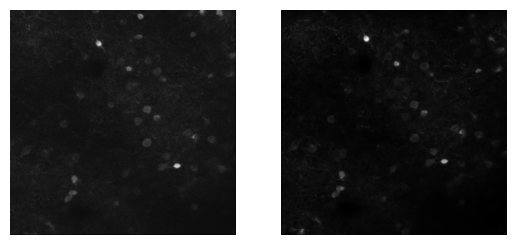

In [181]:
def get_mean_image(emf_fn):
    with h5py.File(emf_fn, 'r') as h:
        mimg = h['data'][:].mean(axis=0)
    return mimg
plane_ind = 0
mimg = get_mean_image(emf_filenames[0])
zstack, matched_zstack_fn = get_zstack(zstack_dir, plane_ind)
zcenter = zstack[zstack.shape[0] //2]
fig, ax = plt.subplots(1, 2)
ax[0].imshow(zcenter, cmap='gray')
ax[0].axis('off')
ax[1].imshow(mimg, cmap='gray')
ax[1].axis('off')


C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22144\713233576.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


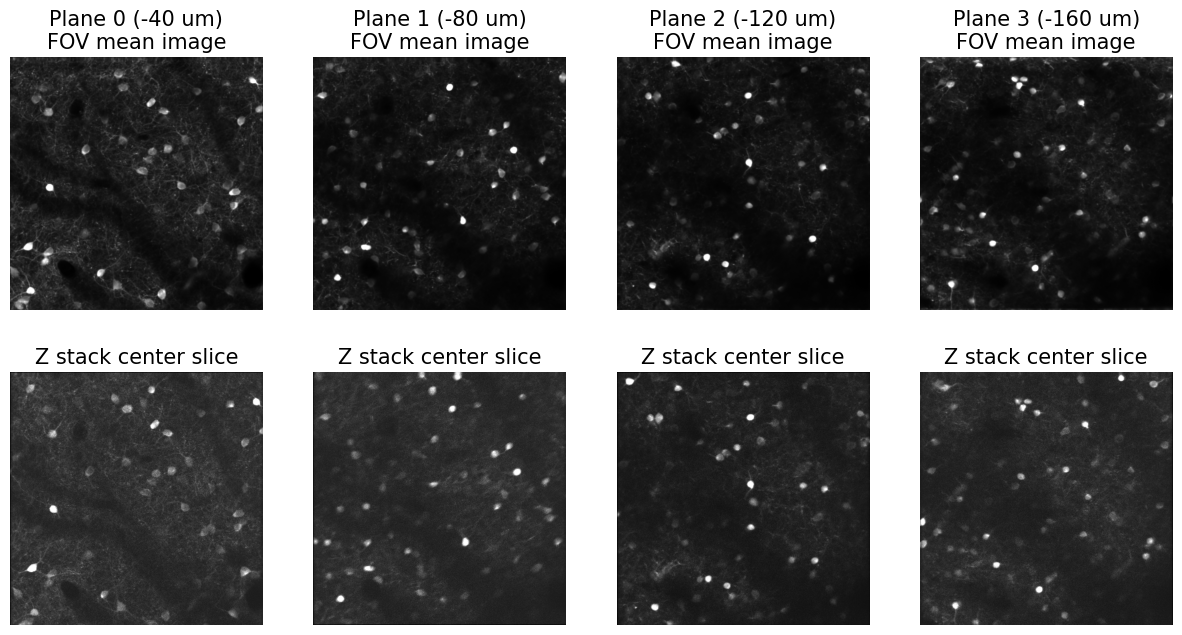

In [206]:
# top plane image comparisons

def compare_mean_fov_zstack(emf_filenames,
                            zstack_dir,
                            plane_nums, 
                            im_adjust_percentiles=[0.02, 99.8]):
    fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
    for pi in range(4):
        plane_num = plane_nums[pi]
        plane_ind = plane_order[plane_num]

        mimg = get_mean_image(emf_filenames[plane_ind])
        zstack, matched_zstack_fn = get_zstack(zstack_dir, plane_ind)
        zcenter = zstack[zstack.shape[0] //2]

        axes[0, pi].imshow(mimg, cmap='gray',
                        vmin=np.percentile(mimg, im_adjust_percentiles[0]),
                        vmax=np.percentile(mimg, im_adjust_percentiles[1]))
        title_str = f'Plane {plane_num} ({-plane_depths[plane_num]} um)'
        title_str += '\nFOV mean image'
        axes[0, pi].set_title(title_str, fontsize=15)
        
        axes[1, pi].imshow(zcenter, cmap='gray',
                        vmin=np.percentile(zcenter, im_adjust_percentiles[0]),
                        vmax=np.percentile(zcenter, im_adjust_percentiles[1]))
        axes[1, pi].set_title('Z stack center slice', fontsize=15)
    for ax in axes.flatten():
        ax.axis('off')
    return fig, axes

plane_nums = [0, 1, 2, 3]
fig, axes = compare_mean_fov_zstack(emf_filenames, zstack_dir, plane_nums)
fig.show()




C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22144\3068172332.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


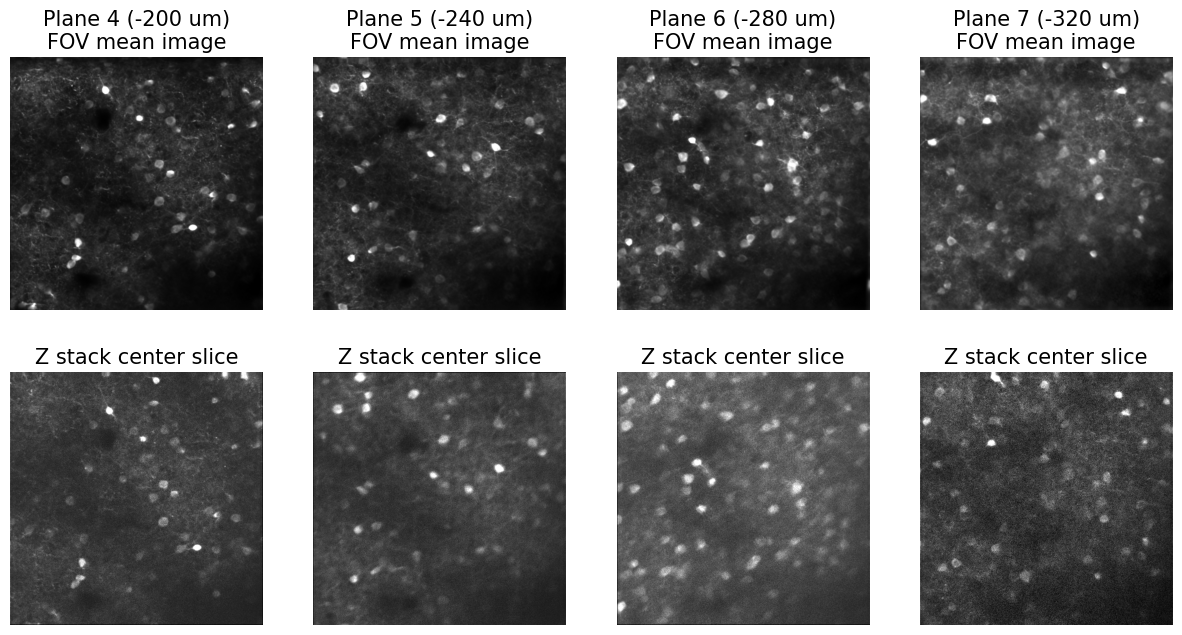

In [208]:
plane_nums = [4, 5, 6, 7]
fig, axes = compare_mean_fov_zstack(emf_filenames, zstack_dir, plane_nums)
fig.show()


### Look at single frame images

In [199]:
# split_filenames = [data_dir / f'{fn_stem}_{pi:02}.h5' for pi in range(num_planes)]

# reg_filenames = list(data_dir.glob(f'{session_name}_timeseries_{file_ind:05}_*_reg.h5'))
split_filenames = [ref_fn.parent / f'{ref_fn.stem.split("_reg")[0]}.h5' for ref_fn in reg_filenames]

In [200]:
split_fn = split_filenames[0]
with h5py.File(split_fn, 'r') as f:
    center_ind = f['data'].shape[0] // 2
    single_frame = f['data'][center_ind]


In [202]:
def get_single_frame(split_fn, frame_ind=None):
    with h5py.File(split_fn, 'r') as f:
        if frame_ind is None:
            center_ind = f['data'].shape[0] // 2
            single_frame = f['data'][center_ind]
        else:
            single_frame = f['data'][frame_ind]
    return single_frame

C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22144\1501971009.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


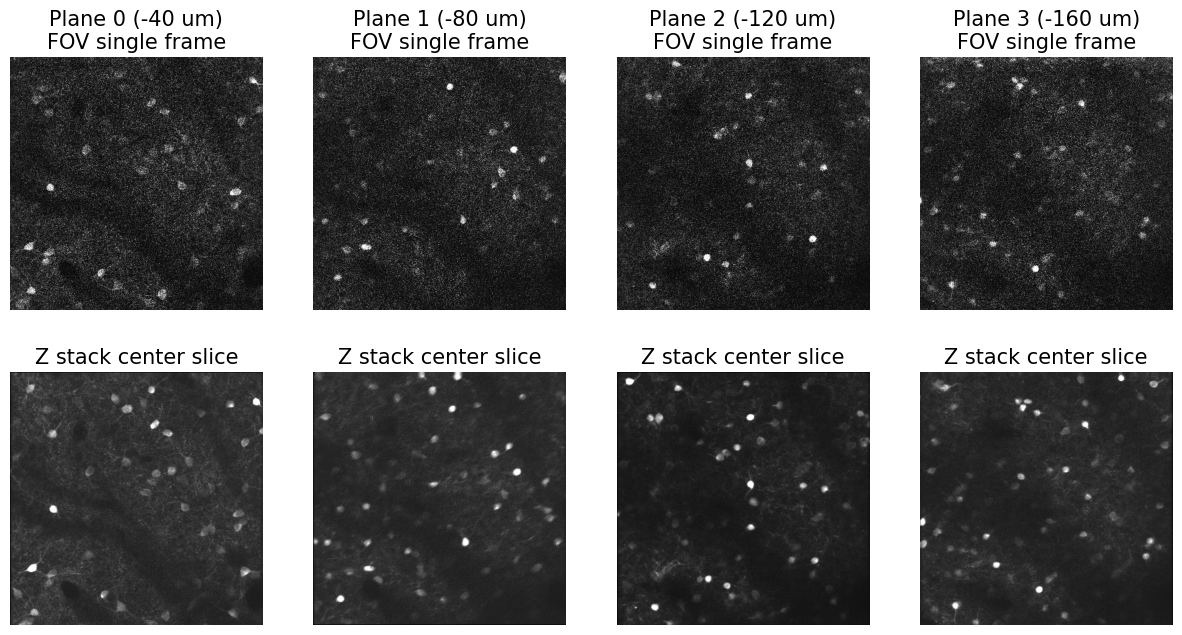

In [211]:
# top plane image comparisons
def compare_single_frame_zstack(split_filenames,
                            zstack_dir,
                            plane_nums, 
                            im_adjust_percentiles=[0.02, 99.8]):
    fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
    for pi in range(4):
        plane_num = plane_nums[pi]
        plane_ind = plane_order[plane_num]

        mimg = get_single_frame(split_filenames[plane_ind])
        zstack, matched_zstack_fn = get_zstack(zstack_dir, plane_ind)
        zcenter = zstack[zstack.shape[0] //2]

        axes[0, pi].imshow(mimg, cmap='gray',
                        vmin=np.percentile(mimg, im_adjust_percentiles[0]),
                        vmax=np.percentile(mimg, im_adjust_percentiles[1]))
        title_str = f'Plane {plane_num} ({-plane_depths[plane_num]} um)'
        title_str += '\nFOV single frame'
        axes[0, pi].set_title(title_str, fontsize=15)
        
        axes[1, pi].imshow(zcenter, cmap='gray',
                        vmin=np.percentile(zcenter, im_adjust_percentiles[0]),
                        vmax=np.percentile(zcenter, im_adjust_percentiles[1]))
        axes[1, pi].set_title('Z stack center slice', fontsize=15)
    for ax in axes.flatten():
        ax.axis('off')
    return fig, axes

plane_nums = [0, 1, 2, 3]
fig, axes = compare_single_frame_zstack(split_filenames, zstack_dir, plane_nums)
fig.show()


C:\Users\jinho.kim\AppData\Local\Temp\ipykernel_22144\1742675379.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


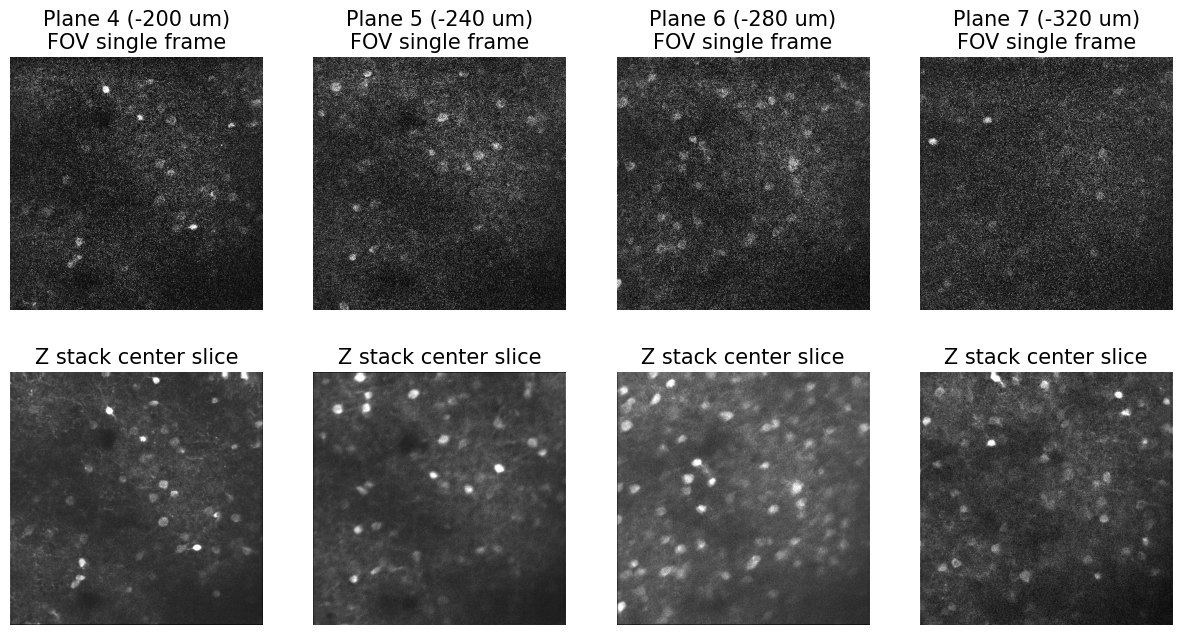

In [212]:
plane_nums = [4, 5, 6, 7]
fig, axes = compare_single_frame_zstack(split_filenames, zstack_dir, plane_nums)
fig.show()